In [2]:
import requests, json, base64
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
with open("tokens.json", "r") as file:
    tokens = json.load(file)

token_url = "https://accounts.spotify.com/api/token"

client_id = "fd5f36cc0ee14678ae37d086ebaf76b2"
client_secret = "152236ac370c43d2b2c4dd47e490c70d"
basic = base64.b64encode(f"{client_id}:{client_secret}".encode()).decode()

access_token = tokens["access_token"]
refresh_token = tokens["refresh_token"]


In [17]:

def refresh():
    global refresh_token, access_token
    body = {"grant_type": "refresh_token",
                 "refresh_token": f"{refresh_token}"}
    headers = {"Content-type": "application/x-www-form-urlencoded",
              "Authorization": f"Basic {basic}"}
    res = requests.post("https://accounts.spotify.com/api/token", headers=headers, data=body)
    if res.status_code == 200:
        tokens = res.json()
        access_token = tokens["access_token"]
        if "refresh_token" in tokens.keys():
            refresh_token = tokens["refresh_token"]
            with open("tokens.json", "w") as file:
                json.dump(tokens, file)
            

def spotify_req(url, params=None):
    headers = {
        "Authorization": f"Bearer {access_token}"
    }
    res = requests.get(url, params = params, headers=headers)
    return res

refresh()

In [36]:
r = spotify_req("https://api.spotify.com/v1/me")
print(r.status_code)
print(r.text)

200
{"country":"NO","display_name":"Jonas Julius Harang","email":"jjharang@msn.com","explicit_content":{"filter_enabled":false,"filter_locked":false},"external_urls":{"spotify":"https://open.spotify.com/user/jonasjul"},"followers":{"href":null,"total":5},"href":"https://api.spotify.com/v1/users/jonasjul","id":"jonasjul","images":[{"height":300,"url":"https://scontent-fra3-1.xx.fbcdn.net/v/t39.30808-1/470024323_10170378430970654_6624611955800743603_n.jpg?stp=c108.28.344.344a_dst-jpg_s320x320_tt6&_nc_cat=108&ccb=1-7&_nc_sid=79bf43&_nc_ohc=JMV_zUjzU0AQ7kNvwF9y_Gl&_nc_oc=AdlQ8KDKfepXsvbAT9vS8Ew_dUuiYWmpQ_s4nnTeKh41a24NwYMCrheGKgtEDIK_EOyGkGkuV-T_bzeB3lZzTk9j&_nc_zt=24&_nc_ht=scontent-fra3-1.xx&edm=AP4hL3IEAAAA&_nc_gid=0faa2OTue9xw0-ie7PcwpQ&_nc_tpa=Q5bMBQFYKXuKhoFG4SeE7J4KbfeD1zo3K56x6G0iBIi8dcUMvSlqz1YHEfWDC0Ilni8UlbH7l8W2&oh=00_AfnLn-PG-uVxE_9uQRGolQG7B54ryrRXmcz8x-8nMY6NEA&oe=6946F46C","width":300},{"height":64,"url":"https://scontent-fra3-1.xx.fbcdn.net/v/t39.30808-1/470024323_10170378

# Mine spillelister
- Vi henter inn mine spillelister
- Analyserer hvilken musikk jeg hører på

## Get playlists
- Hent mine spillelister: [docs](https://developer.spotify.com/documentation/web-api/reference/get-a-list-of-current-users-playlists)

### Putt inn i pandas
- Når vi leser inn data fra en dict i python er typisk:
    - Nøklene er kolonnenavn, og dataene er verdiene i kolonnen
    - Vi kan også ha en liste med dicts, en for hver rad (nøkler = kolonnenavn, verdi = verdi)

In [18]:
api_url = "https://api.spotify.com/v1/"
url = api_url+"me/playlists"
res = spotify_req(url, params={"limit": 50})
data = res.json()

In [19]:
df_playlists = pd.DataFrame(data["items"])
df_playlists = df_playlists[["id", "name"]]
df_playlists

,id,name
0,7ij6XxgvHfDBqXSCxgYUt2,Procol Harum - A Whiter Shade Of Pale (Live in...
1,21lGpvhev1LjKuV2jauZiC,The Irish Rovers
2,15GcrfdDnabxw8zq0bRVfB,Omatt
3,6PYnztH5GLd2xVEAw9Wv9c,
4,1kstE4Tp0wXONRTE1KiJp0,
5,4YpTOwZ0f0MwLgFONtgEqQ,My playlist #10
6,3TF51cnTkvYnzNtWOLONan,Prog für Jonas
7,4MXknL75JdrNKrNUQ6vTGT,Starred
8,3CzhMcwdymIoXlAhoJhMan,PA-top 12
9,0f7KdfesxJoSiV9WiGwkz0,Sommer


In [20]:
df_playlists = pd.json_normalize(data, record_path="items")[["id", "name", "owner.display_name" ]]
df_playlists = df_playlists.query("`owner.display_name`.str.contains('Jonas')")

In [21]:
df_playlists

,id,name,owner.display_name
2,15GcrfdDnabxw8zq0bRVfB,Omatt,Jonas Julius Harang
5,4YpTOwZ0f0MwLgFONtgEqQ,My playlist #10,Jonas Julius Harang
7,4MXknL75JdrNKrNUQ6vTGT,Starred,Jonas Julius Harang
8,3CzhMcwdymIoXlAhoJhMan,PA-top 12,Jonas Julius Harang
9,0f7KdfesxJoSiV9WiGwkz0,Sommer,Jonas Julius Harang
10,3RE1jwiVTY37YxnKzYHs4M,Jazz Standards,Jonas Julius Harang
11,3UC3AAYueCYCS4KQySxs4f,feelgood,Jonas Julius Harang
12,5AJ8F7Oxy44fcisgZCJMBv,hjørnelista,Jonas Julius Harang
15,55iabFP4yPg8KkjNHU5m6o,Top 10 album,Jonas Julius Harang
16,2HWWfK6Fz2SoZGny38GNpM,PA-top 09,Jonas Julius Harang


In [40]:
df_playlists.iloc[0]
listeid = df_playlists.iloc[0]["id"]

res = spotify_req(api_url+f"playlists/{listeid}")
data = res.json()

In [23]:
def get_songs(playlist_id):
    res = spotify_req(api_url+f"playlists/{playlist_id}")
    data = res.json()
    df_part = pd.json_normalize(data, record_path=["tracks", "items", "track", "artists"], 
                  meta=[["tracks", "items", "track", "name"],["tracks", "items", "track", "id"], ["name"]], 
                  errors="ignore", meta_prefix="playlist_")
    return df_part


In [24]:
dfs = [ get_songs(pid) for pid in df_playlists["id"]]


In [38]:
df  = pd.concat(dfs)
df.columns
df = df[["id", "name", 'playlist_tracks.items.track.name', 'playlist_tracks.items.track.id',"playlist_name"]]
#df = df.set_index("playlist_name")
df

,id,name,playlist_tracks.items.track.name,playlist_tracks.items.track.id,playlist_name
0,6T4kUHIlszpj944ZXR3yNw,Maynard Ferguson,Birdland,5riSr1LFW4Bv7JzMNwIc9C,Omatt
1,07icU8dCi2MTeBGuvN8NyL,Mathieu Fiset,Chick's Pain,6IAc8O7MiS2lJiTabpjC7S,Omatt
2,05fG473iIaoy82BF1aGhL8,Slipknot,Wait and Bleed,2gscB6kDOmrv1P6qs2KXE3,Omatt
3,5eAWCfyUhZtHHtBdNk56l1,System Of A Down,Toxicity,0snQkGI5qnAmohLE7jTsTn,Omatt
4,6P7H3ai06vU1sGvdpBwDmE,Steely Dan,Kid Charlemagne,1Ah2XT5vP7kZxS0iXuitik,Omatt
...,...,...,...,...,...
9,776Uo845nYHJpNaStv1Ds4,Jimi Hendrix,All Along The Watchtower,0GuQcX8wTe8bUZ72ZncR7m,Withnail & I
10,776Uo845nYHJpNaStv1Ds4,Jimi Hendrix,Voodoo Chile,0auKlivXpm76wR63mMJ3pR,Withnail & I
11,6l3iPTof4l2D75Wawq9w7R,Al Bowlly,Hang Out the Stars in Indiana,5gOetsfXtgCNWUTHLDu0tV,Withnail & I
12,None,The Beatles,While My Guitar Gently Weeps,None,Withnail & I


## Audo features
- hent audio feature
- Spotify lar deg hente "audio features" for 100 spor (sanger) om gangen
- Audio features er ting som "danceability" osv




In [94]:
def get_Audio_features(ids):
    recco_url = "https://api.reccobeats.com/v1/audio-features"
    n = len(ids)
    offset = 40
    responses = []
    for i in range(0,n,offset):
        params = {"ids": ids[i:i+offset]}
        res = requests.get(recco_url, params=params)
        res.raise_for_status()
        responses.append(res.json())

    songs = []
    for svar in responses:
        songs += svar["content"]
    return songs






In [98]:
playlist_ids = df.groupby(by="playlist_name")["playlist_tracks.items.track.id"].apply(lambda s: s.dropna().unique().tolist())
audio_features = playlist_ids.map(get_Audio_features)

In [154]:
df_feat = audio_features.rename("audio").to_frame().explode("audio").reset_index()
df_feat = pd.concat(
    [df_feat.drop(columns="audio"),
     pd.json_normalize(df_feat["audio"])],
    axis=1
)


def getID(href):
    return href[31:]

df_feat = df_feat.dropna()
df_feat["playlist_tracks.items.track.id"] = df_feat["href"].map(getID)

df_merged = df.merge(df_feat, on=["playlist_name", "playlist_tracks.items.track.id"], how="inner")

In [155]:
df_merged

,id_x,name,playlist_tracks.items.track.name,playlist_tracks.items.track.id,playlist_name,id_y,href,isrc,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
0,6T4kUHIlszpj944ZXR3yNw,Maynard Ferguson,Birdland,5riSr1LFW4Bv7JzMNwIc9C,Omatt,eb915337-6cc7-4af5-bad5-c1469ed4fb2d,https://open.spotify.com/track/5riSr1LFW4Bv7Jz...,USSM10202123,0.014200,0.622,0.6870,0.85000,5.0,0.0746,-12.997,1.0,0.0536,166.737,0.888
1,07icU8dCi2MTeBGuvN8NyL,Mathieu Fiset,Chick's Pain,6IAc8O7MiS2lJiTabpjC7S,Omatt,8697a57d-e840-4d72-addc-702be88040cd,https://open.spotify.com/track/6IAc8O7MiS2lJiT...,ushm21254155,0.410000,0.622,0.7360,0.80000,4.0,0.2440,-11.426,0.0,0.0384,129.821,0.869
2,05fG473iIaoy82BF1aGhL8,Slipknot,Wait and Bleed,2gscB6kDOmrv1P6qs2KXE3,Omatt,3b34918c-568b-4f6d-b74c-fe4ba0a96cec,https://open.spotify.com/track/2gscB6kDOmrv1P6...,NLA329980194,0.002080,0.382,0.9960,0.00000,7.0,0.4170,-4.119,1.0,0.1040,93.345,0.327
3,5eAWCfyUhZtHHtBdNk56l1,System Of A Down,Toxicity,0snQkGI5qnAmohLE7jTsTn,Omatt,ddacc032-e656-44e2-bb33-fd285313bd5d,https://open.spotify.com/track/0snQkGI5qnAmohL...,USSM10107262,0.000264,0.413,0.8730,0.00249,8.0,0.2040,-4.151,1.0,0.0536,116.680,0.480
4,6P7H3ai06vU1sGvdpBwDmE,Steely Dan,Kid Charlemagne,1Ah2XT5vP7kZxS0iXuitik,Omatt,c76e20fd-7331-447e-8308-14ed8102c75a,https://open.spotify.com/track/1Ah2XT5vP7kZxS0...,USMC17547218,0.273000,0.534,0.6900,0.00501,0.0,0.6540,-9.644,1.0,0.0635,95.905,0.763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,7J9Fo9dMjGNYY8usNMietL,Leif Ove Andsnes,"Schubert: Piano Sonata No. 21 in B-Flat Major,...",1NYotQDrTJuaD0RAGGaTHr,Withnail & I,18287679-5de6-4189-890b-4d45cf33fdd0,https://open.spotify.com/track/1NYotQDrTJuaD0R...,GBAYC0401943,0.991000,0.356,0.0879,0.93600,5.0,0.1240,-27.571,0.0,0.0382,128.144,0.488
249,2p0UyoPfYfI76PCStuXfOP,Franz Schubert,"Schubert: Piano Sonata No. 21 in B-Flat Major,...",6uEuNJBvMBieHq94Icok5m,Withnail & I,54bb438a-9682-4a85-8d56-df5cfd83c3bd,https://open.spotify.com/track/6uEuNJBvMBieHq9...,GBAYC0401944,0.992000,0.327,0.1070,0.89800,10.0,0.1220,-23.854,1.0,0.0398,144.535,0.214
250,7J9Fo9dMjGNYY8usNMietL,Leif Ove Andsnes,"Schubert: Piano Sonata No. 21 in B-Flat Major,...",6uEuNJBvMBieHq94Icok5m,Withnail & I,54bb438a-9682-4a85-8d56-df5cfd83c3bd,https://open.spotify.com/track/6uEuNJBvMBieHq9...,GBAYC0401944,0.992000,0.327,0.1070,0.89800,10.0,0.1220,-23.854,1.0,0.0398,144.535,0.214
251,776Uo845nYHJpNaStv1Ds4,Jimi Hendrix,Voodoo Chile,0auKlivXpm76wR63mMJ3pR,Withnail & I,961bb993-d2f7-46c8-8226-4cb2744f2b74,https://open.spotify.com/track/0auKlivXpm76wR6...,USQX90900738,0.248000,0.298,0.7530,0.14800,0.0,0.1120,-7.417,0.0,0.0894,164.991,0.320


### klynge-analyse
- Hvilke spillelister har jeg?
- Hvilke sanger hører jeg på?
- (sammenlikne med top et-eller-annet)

In [165]:
kolonner = list(df_merged.columns)
kolonner_keep = (
[
 'name',
 'playlist_tracks.items.track.name',
 'playlist_name',
 'acousticness',
 'danceability',
 'energy',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'mode',
 'speechiness',
 'tempo',
 'valence'])
df = df_merged[kolonner_keep]
df

,name,playlist_tracks.items.track.name,playlist_name,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
0,Maynard Ferguson,Birdland,Omatt,0.014200,0.622,0.6870,0.85000,5.0,0.0746,-12.997,1.0,0.0536,166.737,0.888
1,Mathieu Fiset,Chick's Pain,Omatt,0.410000,0.622,0.7360,0.80000,4.0,0.2440,-11.426,0.0,0.0384,129.821,0.869
2,Slipknot,Wait and Bleed,Omatt,0.002080,0.382,0.9960,0.00000,7.0,0.4170,-4.119,1.0,0.1040,93.345,0.327
3,System Of A Down,Toxicity,Omatt,0.000264,0.413,0.8730,0.00249,8.0,0.2040,-4.151,1.0,0.0536,116.680,0.480
4,Steely Dan,Kid Charlemagne,Omatt,0.273000,0.534,0.6900,0.00501,0.0,0.6540,-9.644,1.0,0.0635,95.905,0.763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,Leif Ove Andsnes,"Schubert: Piano Sonata No. 21 in B-Flat Major,...",Withnail & I,0.991000,0.356,0.0879,0.93600,5.0,0.1240,-27.571,0.0,0.0382,128.144,0.488
249,Franz Schubert,"Schubert: Piano Sonata No. 21 in B-Flat Major,...",Withnail & I,0.992000,0.327,0.1070,0.89800,10.0,0.1220,-23.854,1.0,0.0398,144.535,0.214
250,Leif Ove Andsnes,"Schubert: Piano Sonata No. 21 in B-Flat Major,...",Withnail & I,0.992000,0.327,0.1070,0.89800,10.0,0.1220,-23.854,1.0,0.0398,144.535,0.214
251,Jimi Hendrix,Voodoo Chile,Withnail & I,0.248000,0.298,0.7530,0.14800,0.0,0.1120,-7.417,0.0,0.0894,164.991,0.320


In [172]:
features = kolonner_keep[3:]
df_pl = df.groupby("playlist_name")[features].mean()
df_pl

,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
playlist_name,,,,,,,,,,,
Jazz Standards,0.778965,0.515838,0.314470,0.277503,4.243243,0.226762,-14.221838,0.810811,0.053151,113.590649,0.541935
Omatt,0.133250,0.512053,0.729211,0.376911,5.210526,0.298989,-8.914158,0.473684,0.056605,116.982526,0.601632
PA-top 09,0.384086,0.339367,0.580969,0.379076,4.900000,0.193447,-8.792067,0.533333,0.048260,118.581000,0.238747
PA-top 12,0.513353,0.402892,0.525692,0.314871,5.769231,0.225374,-10.637308,0.553846,0.036174,127.646185,0.299574
Sommer,0.274746,0.548143,0.637393,0.255858,4.571429,0.298789,-8.721786,0.607143,0.052714,115.067464,0.556036
Starred,0.058300,0.703000,0.778500,0.006860,4.500000,0.112600,-7.569500,1.000000,0.033300,121.740000,0.906500
Top 10 album,0.102603,0.351412,0.654941,0.294797,7.000000,0.216835,-10.375647,0.588235,0.059118,127.175588,0.524471
Withnail & I,0.890400,0.321400,0.144968,0.803300,5.200000,0.170000,-25.236100,0.500000,0.046830,109.606100,0.210420
feelgood,0.330444,0.550778,0.578222,0.343959,4.222222,0.274300,-10.875333,0.777778,0.080389,135.125000,0.608556


In [171]:
#Ta med spredning
df_pl_std = df.groupby("playlist_name")[features].std().add_suffix("_std")
df_pl2 = df_pl.join(df_pl_std)
df_pl2

,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,...,danceability_std,energy_std,instrumentalness_std,key_std,liveness_std,loudness_std,mode_std,speechiness_std,tempo_std,valence_std
playlist_name,,,,,,,,,,,,,,,,,,,,,
Jazz Standards,0.778965,0.515838,0.314470,0.277503,4.243243,0.226762,-14.221838,0.810811,0.053151,113.590649,...,0.155066,0.186646,0.383366,3.451291,0.233621,3.978713,0.397061,0.039878,29.461585,0.263722
Omatt,0.133250,0.512053,0.729211,0.376911,5.210526,0.298989,-8.914158,0.473684,0.056605,116.982526,...,0.103085,0.162914,0.357977,3.207265,0.261528,2.716506,0.512989,0.028133,21.246174,0.205443
PA-top 09,0.384086,0.339367,0.580969,0.379076,4.900000,0.193447,-8.792067,0.533333,0.048260,118.581000,...,0.130106,0.276248,0.354179,3.994393,0.144494,3.480026,0.507416,0.023572,25.627123,0.187845
PA-top 12,0.513353,0.402892,0.525692,0.314871,5.769231,0.225374,-10.637308,0.553846,0.036174,127.646185,...,0.139654,0.208896,0.378888,3.521227,0.198844,4.312277,0.500961,0.011256,25.090343,0.207038
Sommer,0.274746,0.548143,0.637393,0.255858,4.571429,0.298789,-8.721786,0.607143,0.052714,115.067464,...,0.157448,0.219467,0.348605,3.532165,0.282862,3.455828,0.497347,0.029039,19.691475,0.216319
Starred,0.058300,0.703000,0.778500,0.006860,4.500000,0.112600,-7.569500,1.000000,0.033300,121.740000,...,0.021213,0.038891,0.009674,0.707107,0.027436,2.293147,0.000000,0.006081,0.356382,0.031820
Top 10 album,0.102603,0.351412,0.654941,0.294797,7.000000,0.216835,-10.375647,0.588235,0.059118,127.175588,...,0.136892,0.136718,0.246783,2.893959,0.147213,2.108266,0.507300,0.035631,37.443050,0.196970
Withnail & I,0.890400,0.321400,0.144968,0.803300,5.200000,0.170000,-25.236100,0.500000,0.046830,109.606100,...,0.057027,0.224658,0.244425,4.491968,0.211448,7.929029,0.527046,0.015799,36.725598,0.177458
feelgood,0.330444,0.550778,0.578222,0.343959,4.222222,0.274300,-10.875333,0.777778,0.080389,135.125000,...,0.194520,0.213879,0.429901,3.898005,0.248354,3.440681,0.440959,0.048751,25.701818,0.254118


In [174]:
df_pl = df_pl2
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = StandardScaler().fit_transform(df_pl)


inertia = []
K = range(2, 10)

for k in K:
    inertia.append(KMeans(k, random_state=0).fit(X).inertia_)

kmeans = KMeans(n_clusters=5, random_state=0)
df_pl["cluster"] = kmeans.fit_predict(X)



In [176]:
cluster_profiles = (
    df_pl
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profiles


,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
cluster,,,,,,,,,,,
0,0.06,0.70,0.78,0.01,4.50,0.11,-7.57,1.00,0.03,121.74,0.91
1,0.09,0.41,0.67,0.23,6.78,0.21,-9.40,0.60,0.06,126.15,0.53
2,0.38,0.53,0.56,0.31,4.56,0.27,-10.68,0.67,0.06,120.19,0.58
3,0.89,0.32,0.14,0.80,5.20,0.17,-25.24,0.50,0.05,109.61,0.21
4,0.45,0.37,0.55,0.35,5.33,0.21,-9.71,0.54,0.04,123.11,0.27


In [177]:
df_pl[["cluster"]].sort_values("cluster")


,cluster
playlist_name,
Starred,0
Top 10 album,1
hjørnelista,1
Jazz Standards,2
Omatt,2
Sommer,2
feelgood,2
Withnail & I,3
PA-top 09,4


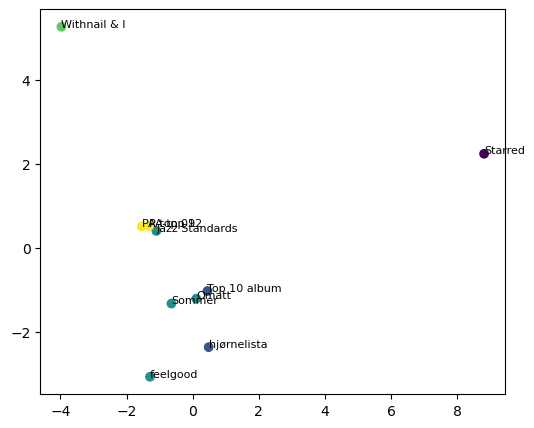

In [180]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_pca = PCA(n_components=2).fit_transform(X)

df_vis = df_pl.reset_index()
df_vis["pc1"] = X_pca[:,0]
df_vis["pc2"] = X_pca[:,1]



plt.figure(figsize=(6,5))
plt.scatter(df_vis["pc1"], df_vis["pc2"], c=df_vis["cluster"])
for _, r in df_vis.iterrows():
    plt.text(r.pc1, r.pc2, r.playlist_name, fontsize=8)
plt.show()



## KLADD

In [186]:
data = res.json()
df_tracks = pd.json_normalize(data, record_path=["tracks","items"])
#data["tracks"]["items"][0]["track"]["name"]
df_tracks.head(3)
data["name"]

'Omatt'

In [184]:
data["tracks"]["items"][0]["track"]["artists"]
#pd.json_normalize(data, record_path=["tracks", "items"])

[{'external_urls': {'spotify': 'https://open.spotify.com/artist/6T4kUHIlszpj944ZXR3yNw'},
  'href': 'https://api.spotify.com/v1/artists/6T4kUHIlszpj944ZXR3yNw',
  'id': '6T4kUHIlszpj944ZXR3yNw',
  'name': 'Maynard Ferguson',
  'type': 'artist',
  'uri': 'spotify:artist:6T4kUHIlszpj944ZXR3yNw'}]

In [159]:
df_tracks = pd.json_normalize(data, record_path=["tracks", "items"], meta=["id", "name"], errors="ignore")

In [ ]:
data["tracks"]["items"][0]["track"].keys()

In [165]:
df_tracks["track.artists"].iloc[0]
def getartist(artists):
    return artists[0]["name"]

df_tracks["artist"] = df_tracks["track.artists"].map(getartist)
df_tracks.columns


Index(['added_at', 'is_local', 'primary_color',
       'added_by.external_urls.spotify', 'added_by.href', 'added_by.id',
       'added_by.type', 'added_by.uri', 'track.preview_url',
       'track.available_markets', 'track.explicit', 'track.type',
       'track.episode', 'track.track', 'track.album.available_markets',
       'track.album.type', 'track.album.album_type', 'track.album.href',
       'track.album.id', 'track.album.images', 'track.album.name',
       'track.album.release_date', 'track.album.release_date_precision',
       'track.album.uri', 'track.album.artists',
       'track.album.external_urls.spotify', 'track.album.total_tracks',
       'track.artists', 'track.disc_number', 'track.track_number',
       'track.duration_ms', 'track.external_ids.isrc',
       'track.external_urls.spotify', 'track.href', 'track.id', 'track.name',
       'track.popularity', 'track.uri', 'track.is_local',
       'video_thumbnail.url', 'id', 'name', 'artist'],
      dtype='object')

In [196]:
pd.json_normalize(data, record_path=["tracks", "items", "track", "artists"], 
                  meta=[["tracks", "items", "track", "name"],["tracks", "items", "track", "id"], ["name"]], 
                  errors="ignore", meta_prefix="playlist_")


,href,id,name,type,uri,external_urls.spotify,playlist_tracks.items.track.name,playlist_tracks.items.track.id,playlist_name
0,https://api.spotify.com/v1/artists/6T4kUHIlszp...,6T4kUHIlszpj944ZXR3yNw,Maynard Ferguson,artist,spotify:artist:6T4kUHIlszpj944ZXR3yNw,https://open.spotify.com/artist/6T4kUHIlszpj94...,Birdland,5riSr1LFW4Bv7JzMNwIc9C,Omatt
1,https://api.spotify.com/v1/artists/07icU8dCi2M...,07icU8dCi2MTeBGuvN8NyL,Mathieu Fiset,artist,spotify:artist:07icU8dCi2MTeBGuvN8NyL,https://open.spotify.com/artist/07icU8dCi2MTeB...,Chick's Pain,6IAc8O7MiS2lJiTabpjC7S,Omatt
2,https://api.spotify.com/v1/artists/05fG473iIao...,05fG473iIaoy82BF1aGhL8,Slipknot,artist,spotify:artist:05fG473iIaoy82BF1aGhL8,https://open.spotify.com/artist/05fG473iIaoy82...,Wait and Bleed,2gscB6kDOmrv1P6qs2KXE3,Omatt
3,https://api.spotify.com/v1/artists/5eAWCfyUhZt...,5eAWCfyUhZtHHtBdNk56l1,System Of A Down,artist,spotify:artist:5eAWCfyUhZtHHtBdNk56l1,https://open.spotify.com/artist/5eAWCfyUhZtHHt...,Toxicity,0snQkGI5qnAmohLE7jTsTn,Omatt
4,https://api.spotify.com/v1/artists/6P7H3ai06vU...,6P7H3ai06vU1sGvdpBwDmE,Steely Dan,artist,spotify:artist:6P7H3ai06vU1sGvdpBwDmE,https://open.spotify.com/artist/6P7H3ai06vU1sG...,Kid Charlemagne,1Ah2XT5vP7kZxS0iXuitik,Omatt
5,https://api.spotify.com/v1/artists/0HtEZODdzPz...,0HtEZODdzPzZhdehDcF3fX,Freak Kitchen,artist,spotify:artist:0HtEZODdzPzZhdehDcF3fX,https://open.spotify.com/artist/0HtEZODdzPzZhd...,Michael & The Syndrome,5EIrZAT9fT304ZjCWiFJEp,Omatt
6,https://api.spotify.com/v1/artists/7pXu47GoqSY...,7pXu47GoqSYRajmBCjxdD6,Vulfpeck,artist,spotify:artist:7pXu47GoqSYRajmBCjxdD6,https://open.spotify.com/artist/7pXu47GoqSYRaj...,Dean Town (Live at Madison Square Garden),7MNhvUp3m9ZZLVnpiRtUjJ,Omatt
7,https://api.spotify.com/v1/artists/19MZg9MYc5x...,19MZg9MYc5xw08l09RCfrT,Guthrie Govan,artist,spotify:artist:19MZg9MYc5xw08l09RCfrT,https://open.spotify.com/artist/19MZg9MYc5xw08...,Wonderful Slippery Thing,3MbHBhGhJr7anwlETNVTRA,Omatt
8,https://api.spotify.com/v1/artists/4CxobvwTpmf...,4CxobvwTpmfpIEbkYh4pAb,Eric Johnson,artist,spotify:artist:4CxobvwTpmfpIEbkYh4pAb,https://open.spotify.com/artist/4CxobvwTpmfpIE...,Cliffs Of Dover - Instrumental,5qm0KiVKMXW1kq6VrnIhz5,Omatt
9,https://api.spotify.com/v1/artists/7AC976RDJzL...,7AC976RDJzL2asmZuz7qil,Yes,artist,spotify:artist:7AC976RDJzL2asmZuz7qil,https://open.spotify.com/artist/7AC976RDJzL2as...,Roundabout - 2024 Remaster,466C6kwoJHLUJ8VHG98hCY,Omatt


In [196]:
df_tr = df.set_index(["name", "playlist_tracks.items.track.name"]).sort_index()[features]
df_tr

acousticness  \
name                  playlist_tracks.items.track.name                                   
3rdegree              A Nihilist's Love Song                                   0.15000   
                      A Work of Art                                            0.78300   
                      Exit Strategy                                            0.32000   
                      Incoherent Ramblings                                     0.49200   
                      Memetic Pandemic                                         0.14400   
...                                                                                ...   
Yes                   Starship Trooper: a. Life Seeker, b. Disillusio...       0.00883   
                      Yours Is No Disgrace                                     0.00396   
Youngblood Brass Band Brooklyn                                                 0.06490   
                      Round One                                                0.02070   
pennybirdrabbit       All I Ask of You (feat. Pennybirdrabbit)                 0.01730   

                                                                          danceability  \
name                  playlist_tracks.items.track.name                                   
3rdegree              A Nihilist's Love Song                                     0.443   
                      A Work of Art                                              0.610   
                      Exit Strategy                                              0.595   
                      Incoherent Ramblings                                       0.635   
                      Memetic Pandemic                                           0.365   
...                                                                                ...   
Yes                   Starship Trooper: a. Life Seeker, b. Disillusio...         0.336   
                      Yours Is No Disgrace                                       0.412   
Youngblood Brass Band Brooklyn                                                   0.442   
                      Round One                                                  0.519   
pennybirdrabbit       All I Ask of You (feat. Pennybirdrabbit)                   0.774   

                                                                          energy  \
name                  playlist_tracks.items.track.name                             
3rdegree              A Nihilist's Love Song                               0.496   
                      A Work of Art                                        0.341   
                      Exit Strategy                                        0.566   
                      Incoherent Ramblings                                 0.684   
                      Memetic Pandemic                                     0.469   
...                                                                          ...   
Yes                   Starship Trooper: a. Life Seeker, b. Disillusio...   0.525   
                      Yours Is No Disgrace                                 0.629   
Youngblood Brass Band Brooklyn                                             0.794   
                      Round One                                            0.929   
pennybirdrabbit       All I Ask of You (feat. Pennybirdrabbit)             0.909   

                                                                          instrumentalness  \
name                  playlist_tracks.items.track.name                                       
3rdegree              A Nihilist's Love Song                                      0.000000   
                      A Work of Art                                               0.000371   
                      Exit Strategy                                               0.000115   
                      Incoherent Ramblings                                        0.000032   
                      Memetic Pandemic                                     

In [198]:

X = StandardScaler().fit_transform(df_tr)

kmeans = KMeans(n_clusters=5, random_state=0)
df_tr["cluster"] = kmeans.fit_predict(X)
cluster_profiles = (
    df_tr
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profiles


,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
cluster,,,,,,,,,,,
0,0.89,0.31,0.20,0.73,5.00,0.17,-19.91,0.75,0.04,98.58,0.15
1,0.04,0.32,0.85,0.41,4.31,0.26,-7.21,0.27,0.10,142.48,0.43
2,0.30,0.59,0.67,0.31,6.15,0.26,-9.02,0.73,0.06,117.24,0.69
3,0.24,0.35,0.58,0.24,7.10,0.22,-9.27,0.38,0.04,128.85,0.29
4,0.64,0.48,0.36,0.05,2.48,0.22,-12.09,0.78,0.04,123.64,0.38


In [199]:
df_tr

acousticness  \
name                  playlist_tracks.items.track.name                                   
3rdegree              A Nihilist's Love Song                                   0.15000   
                      A Work of Art                                            0.78300   
                      Exit Strategy                                            0.32000   
                      Incoherent Ramblings                                     0.49200   
                      Memetic Pandemic                                         0.14400   
...                                                                                ...   
Yes                   Starship Trooper: a. Life Seeker, b. Disillusio...       0.00883   
                      Yours Is No Disgrace                                     0.00396   
Youngblood Brass Band Brooklyn                                                 0.06490   
                      Round One                                                0.02070   
pennybirdrabbit       All I Ask of You (feat. Pennybirdrabbit)                 0.01730   

                                                                          danceability  \
name                  playlist_tracks.items.track.name                                   
3rdegree              A Nihilist's Love Song                                     0.443   
                      A Work of Art                                              0.610   
                      Exit Strategy                                              0.595   
                      Incoherent Ramblings                                       0.635   
                      Memetic Pandemic                                           0.365   
...                                                                                ...   
Yes                   Starship Trooper: a. Life Seeker, b. Disillusio...         0.336   
                      Yours Is No Disgrace                                       0.412   
Youngblood Brass Band Brooklyn                                                   0.442   
                      Round One                                                  0.519   
pennybirdrabbit       All I Ask of You (feat. Pennybirdrabbit)                   0.774   

                                                                          energy  \
name                  playlist_tracks.items.track.name                             
3rdegree              A Nihilist's Love Song                               0.496   
                      A Work of Art                                        0.341   
                      Exit Strategy                                        0.566   
                      Incoherent Ramblings                                 0.684   
                      Memetic Pandemic                                     0.469   
...                                                                          ...   
Yes                   Starship Trooper: a. Life Seeker, b. Disillusio...   0.525   
                      Yours Is No Disgrace                                 0.629   
Youngblood Brass Band Brooklyn                                             0.794   
                      Round One                                            0.929   
pennybirdrabbit       All I Ask of You (feat. Pennybirdrabbit)             0.909   

                                                                          instrumentalness  \
name                  playlist_tracks.items.track.name                                       
3rdegree              A Nihilist's Love Song                                      0.000000   
                      A Work of Art                                               0.000371   
                      Exit Strategy                                               0.000115   
                      Incoherent Ramblings                                        0.000032   
                      Memetic Pandemic                                     

In [211]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_tr["pc1"] = X_pca[:, 0]
df_tr["pc2"] = X_pca[:, 1]

print(pca.explained_variance_ratio_)


[0.28318456 0.15964808]


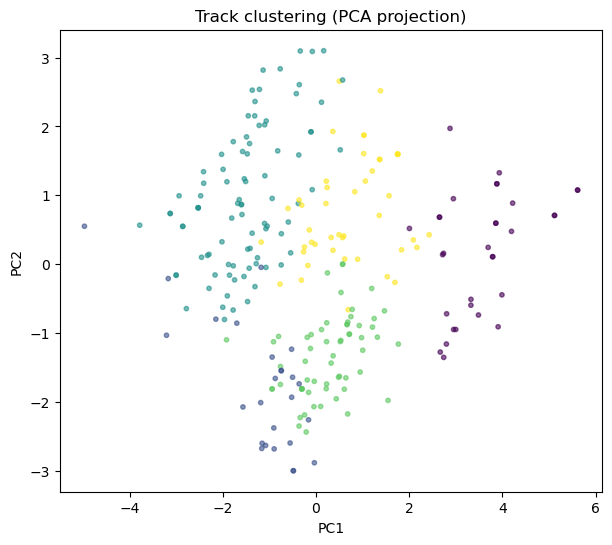

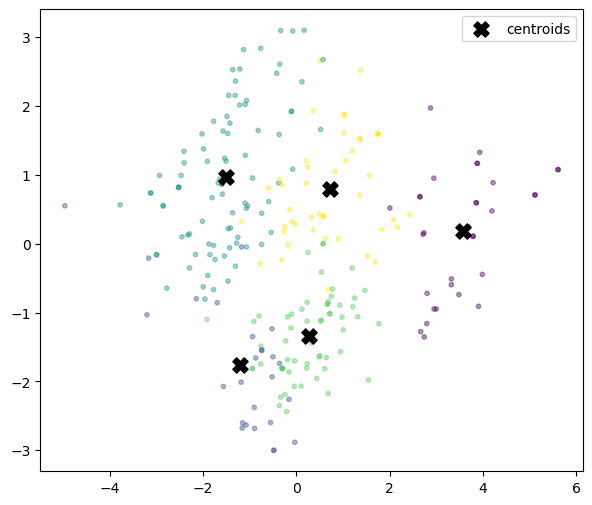

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(
    df_tr["pc1"],
    df_tr["pc2"],
    c=df_tr["cluster"],
    s=10,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Track clustering (PCA projection)")
plt.show()

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7, 6))
plt.scatter(df_tr["pc1"], df_tr["pc2"], c=df_tr["cluster"], s=10, alpha=0.4)
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c="black",
    s=120,
    marker="X",
    label="centroids"
)
plt.legend()
plt.show()



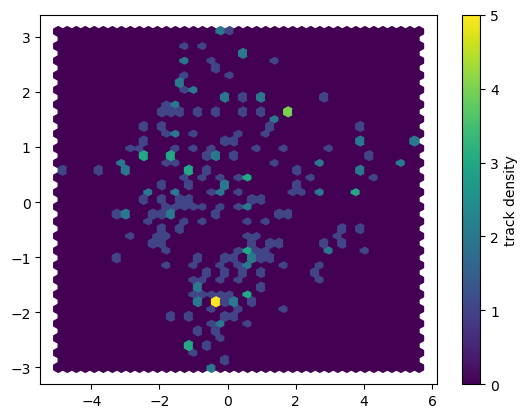

In [217]:
plt.hexbin(df_tr["pc1"], df_tr["pc2"], gridsize=40)
plt.colorbar(label="track density")
